# Heart Disease Prediction Midterm Project

**Course topics applied:** data preprocessing, pattern mining, basic classification, and advanced classification.

**Dataset:** Kaggle - *Heart Disease Dataset* (`heart.csv` after download/rename)

This notebook is designed as a complete midterm project template:
- clean and preprocess the data
- explore the target distribution and feature relationships
- mine useful patterns with association rules
- compare several baseline classifiers
- try stronger ensemble models
- pick the best model and save it for reuse


1. Predict whether a patient has heart disease from clinical attributes.
2. Apply preprocessing techniques such as missing-value handling, encoding, scaling, and outlier treatment.
3. Use pattern mining to discover interesting combinations of features related to heart disease.
4. Compare basic classifiers with advanced ensemble methods.
5. Build a reproducible pipeline that can be rerun after downloading the Kaggle dataset.

In [ ]:
3

In [145]:
import os
import warnings
warnings.filterwarnings("ignore")
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial"],
    "font.size":        9,
    "axes.titlesize":   10,
    "axes.labelsize":   9,
    "xtick.labelsize":  8,
    "ytick.labelsize":  8,
    "legend.fontsize":  8,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "savefig.format":   "tiff",
})

# Palette MDPI: readable cả màu lẫn đen trắng
# Dùng màu + pattern/marker để phân biệt khi in grayscale
MDPI_COLORS = ["#0072B2", "#E69F00", "#009E73",
               "#CC79A7", "#56B4E9"]

# Palette đọc được cả màu lẫn đen trắng
PALETTE = ["#2166ac", "#d6604d", "#4dac26", "#762a83", "#f4a582"]
GRAY_PALETTE = ["#1a1a1a", "#636363", "#969696", "#cccccc", "#f7f7f7"]
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.neural_network import MLPClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [146]:
# Optional dependency for association rules
try:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules
except ImportError:
    import sys
    !{sys.executable} -m pip install mlxtend
    from mlxtend.preprocessing import TransactionEncoder

## 2. Load the dataset

After downloading the Kaggle dataset, place the file in the same folder as this notebook and name it `heart.csv`.

If your file has a different name, change `DATA_PATH` below.

In [147]:
dataset_path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", dataset_path)

def find_csv_file(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.endswith(".csv"):
                return os.path.join(root, file)
    raise FileNotFoundError("Không tìm thấy file CSV trong dataset")

csv_path = find_csv_file(dataset_path)

# Load dữ liệu
df = pd.read_csv(csv_path)

print(f"Loaded: {csv_path}")
print("Shape:", df.shape)
print(df.head())

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Path to dataset files: /kaggle/input/heart-failure-prediction
Loaded: /kaggle/input/heart-failure-prediction/heart.csv
Shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up         

## 3. Initial inspection

In [148]:
display(df.head())
print(df.info())
print("\nMissing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget value counts:")
print(df["HeartDisease"].value_counts(dropna=False))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseA

In [149]:
# Basic summary statistics
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


## 4. Data preprocessing

The heart-disease dataset is usually stored as a clean tabular dataset, but we still apply a full preprocessing workflow:
- remove duplicates
- treat outliers using IQR clipping for continuous variables
- impute missing values
- encode categorical features
- scale numerical features

In [150]:
# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

target_col = "HeartDisease" if "HeartDisease" in df.columns else df.columns[-1]

# Common column groups in the Kaggle heart dataset
known_categorical = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]
cat_cols = [c for c in known_categorical if c in df.columns and c != target_col]
num_cols = [c for c in df.columns if c not in cat_cols + [target_col]]

print("Target column:", target_col)
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Target column: HeartDisease
Categorical columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


In [151]:
# IQR clipping for numeric columns (conservative outlier treatment)
def iqr_clip(frame, columns, factor=1.5):
    out = frame.copy()
    bounds = {}
    for col in columns:
        q1 = out[col].quantile(0.25)
        q3 = out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        out[col] = out[col].clip(lower, upper)
        bounds[col] = (lower, upper)
    return out, bounds

df_clean, outlier_bounds = iqr_clip(df, [c for c in num_cols if c != target_col])
print("Applied IQR clipping to:", list(outlier_bounds.keys()))

Applied IQR clipping to: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


In [152]:
# Check missing values again after cleaning step
print(df_clean.isna().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


### 4.1 Exploratory analysis

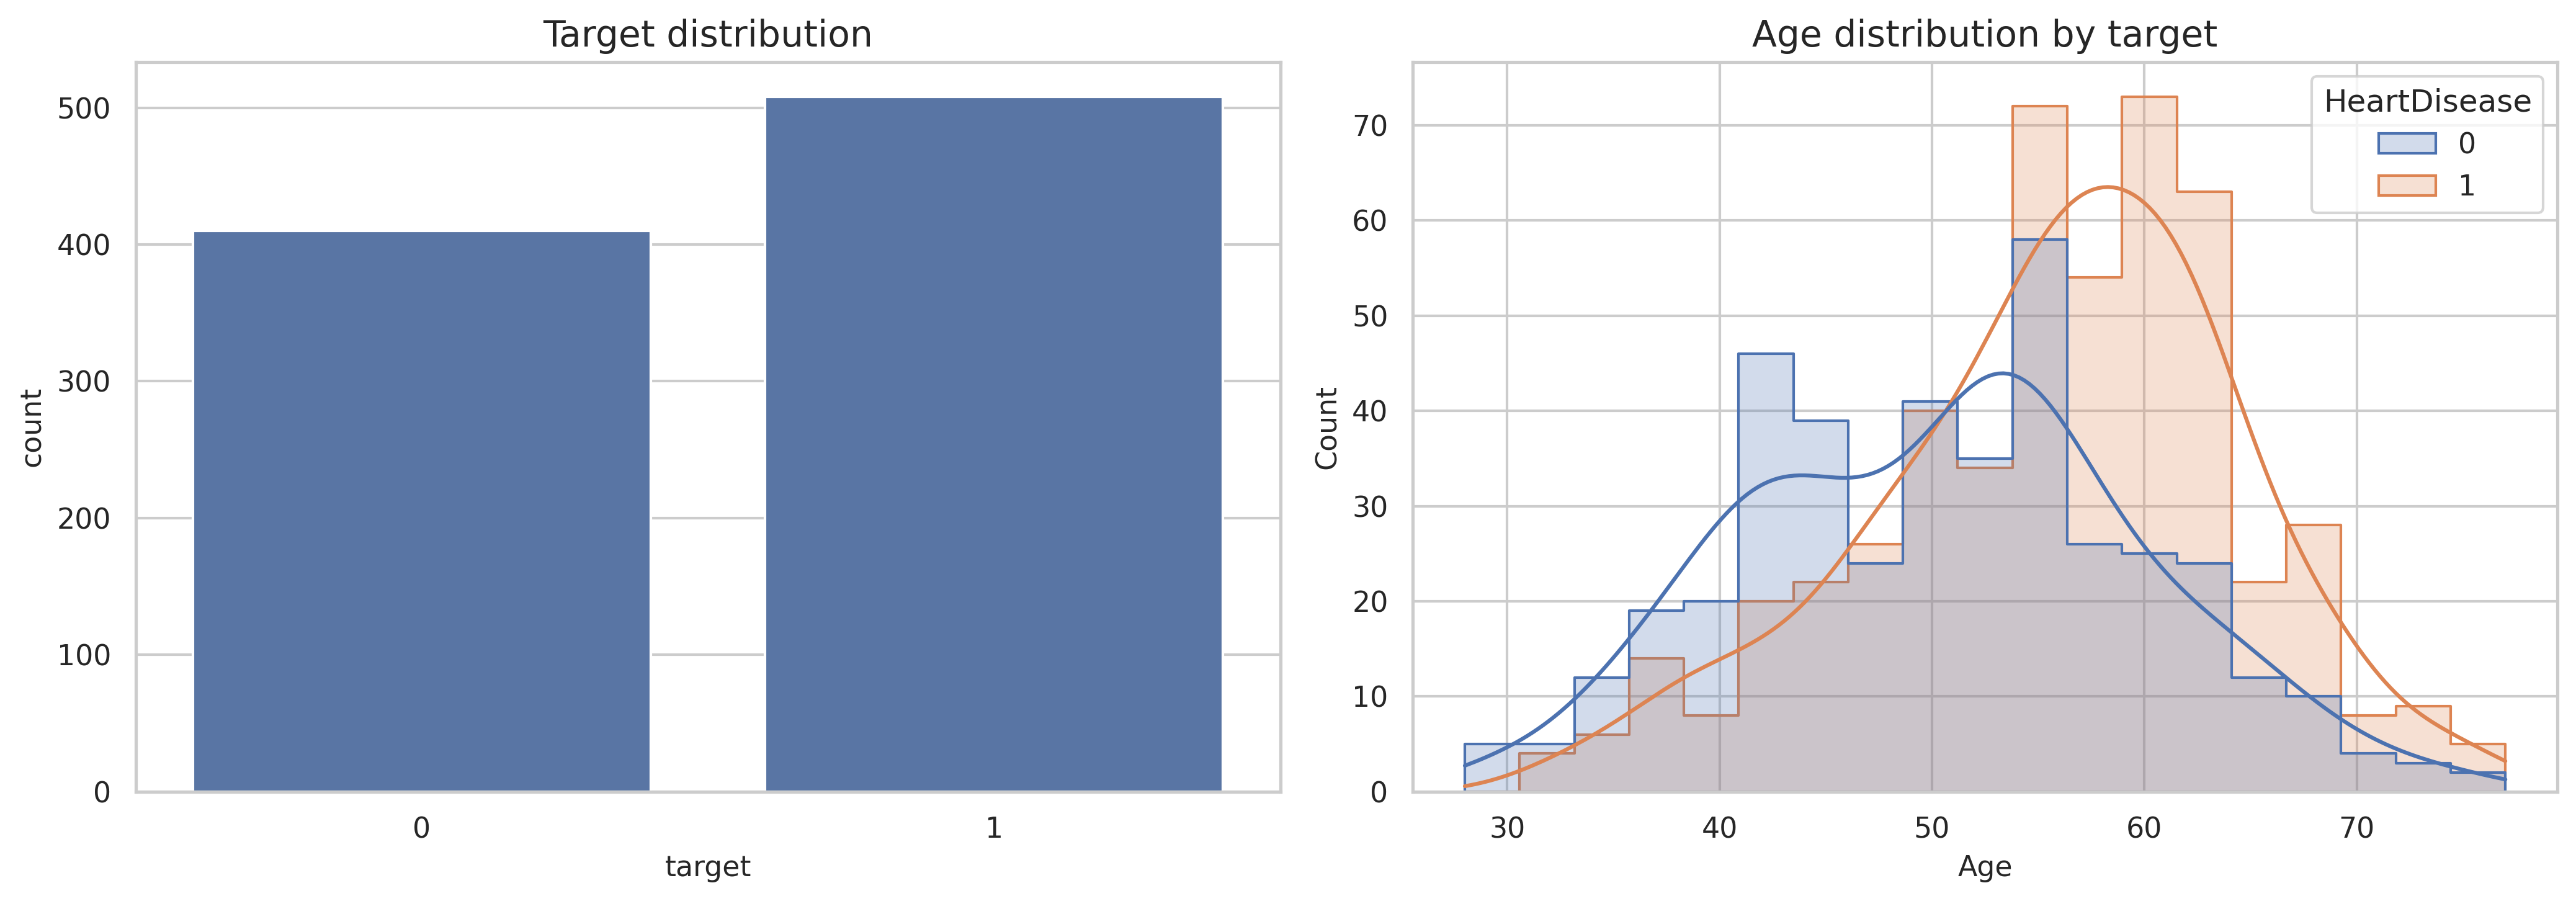

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x=target_col, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("target")
axes[0].set_ylabel("count")

if "Age" in df_clean.columns:
    sns.histplot(data=df_clean, x="Age", hue=target_col, kde=True, element="step", ax=axes[1])
    axes[1].set_title("Age distribution by target")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

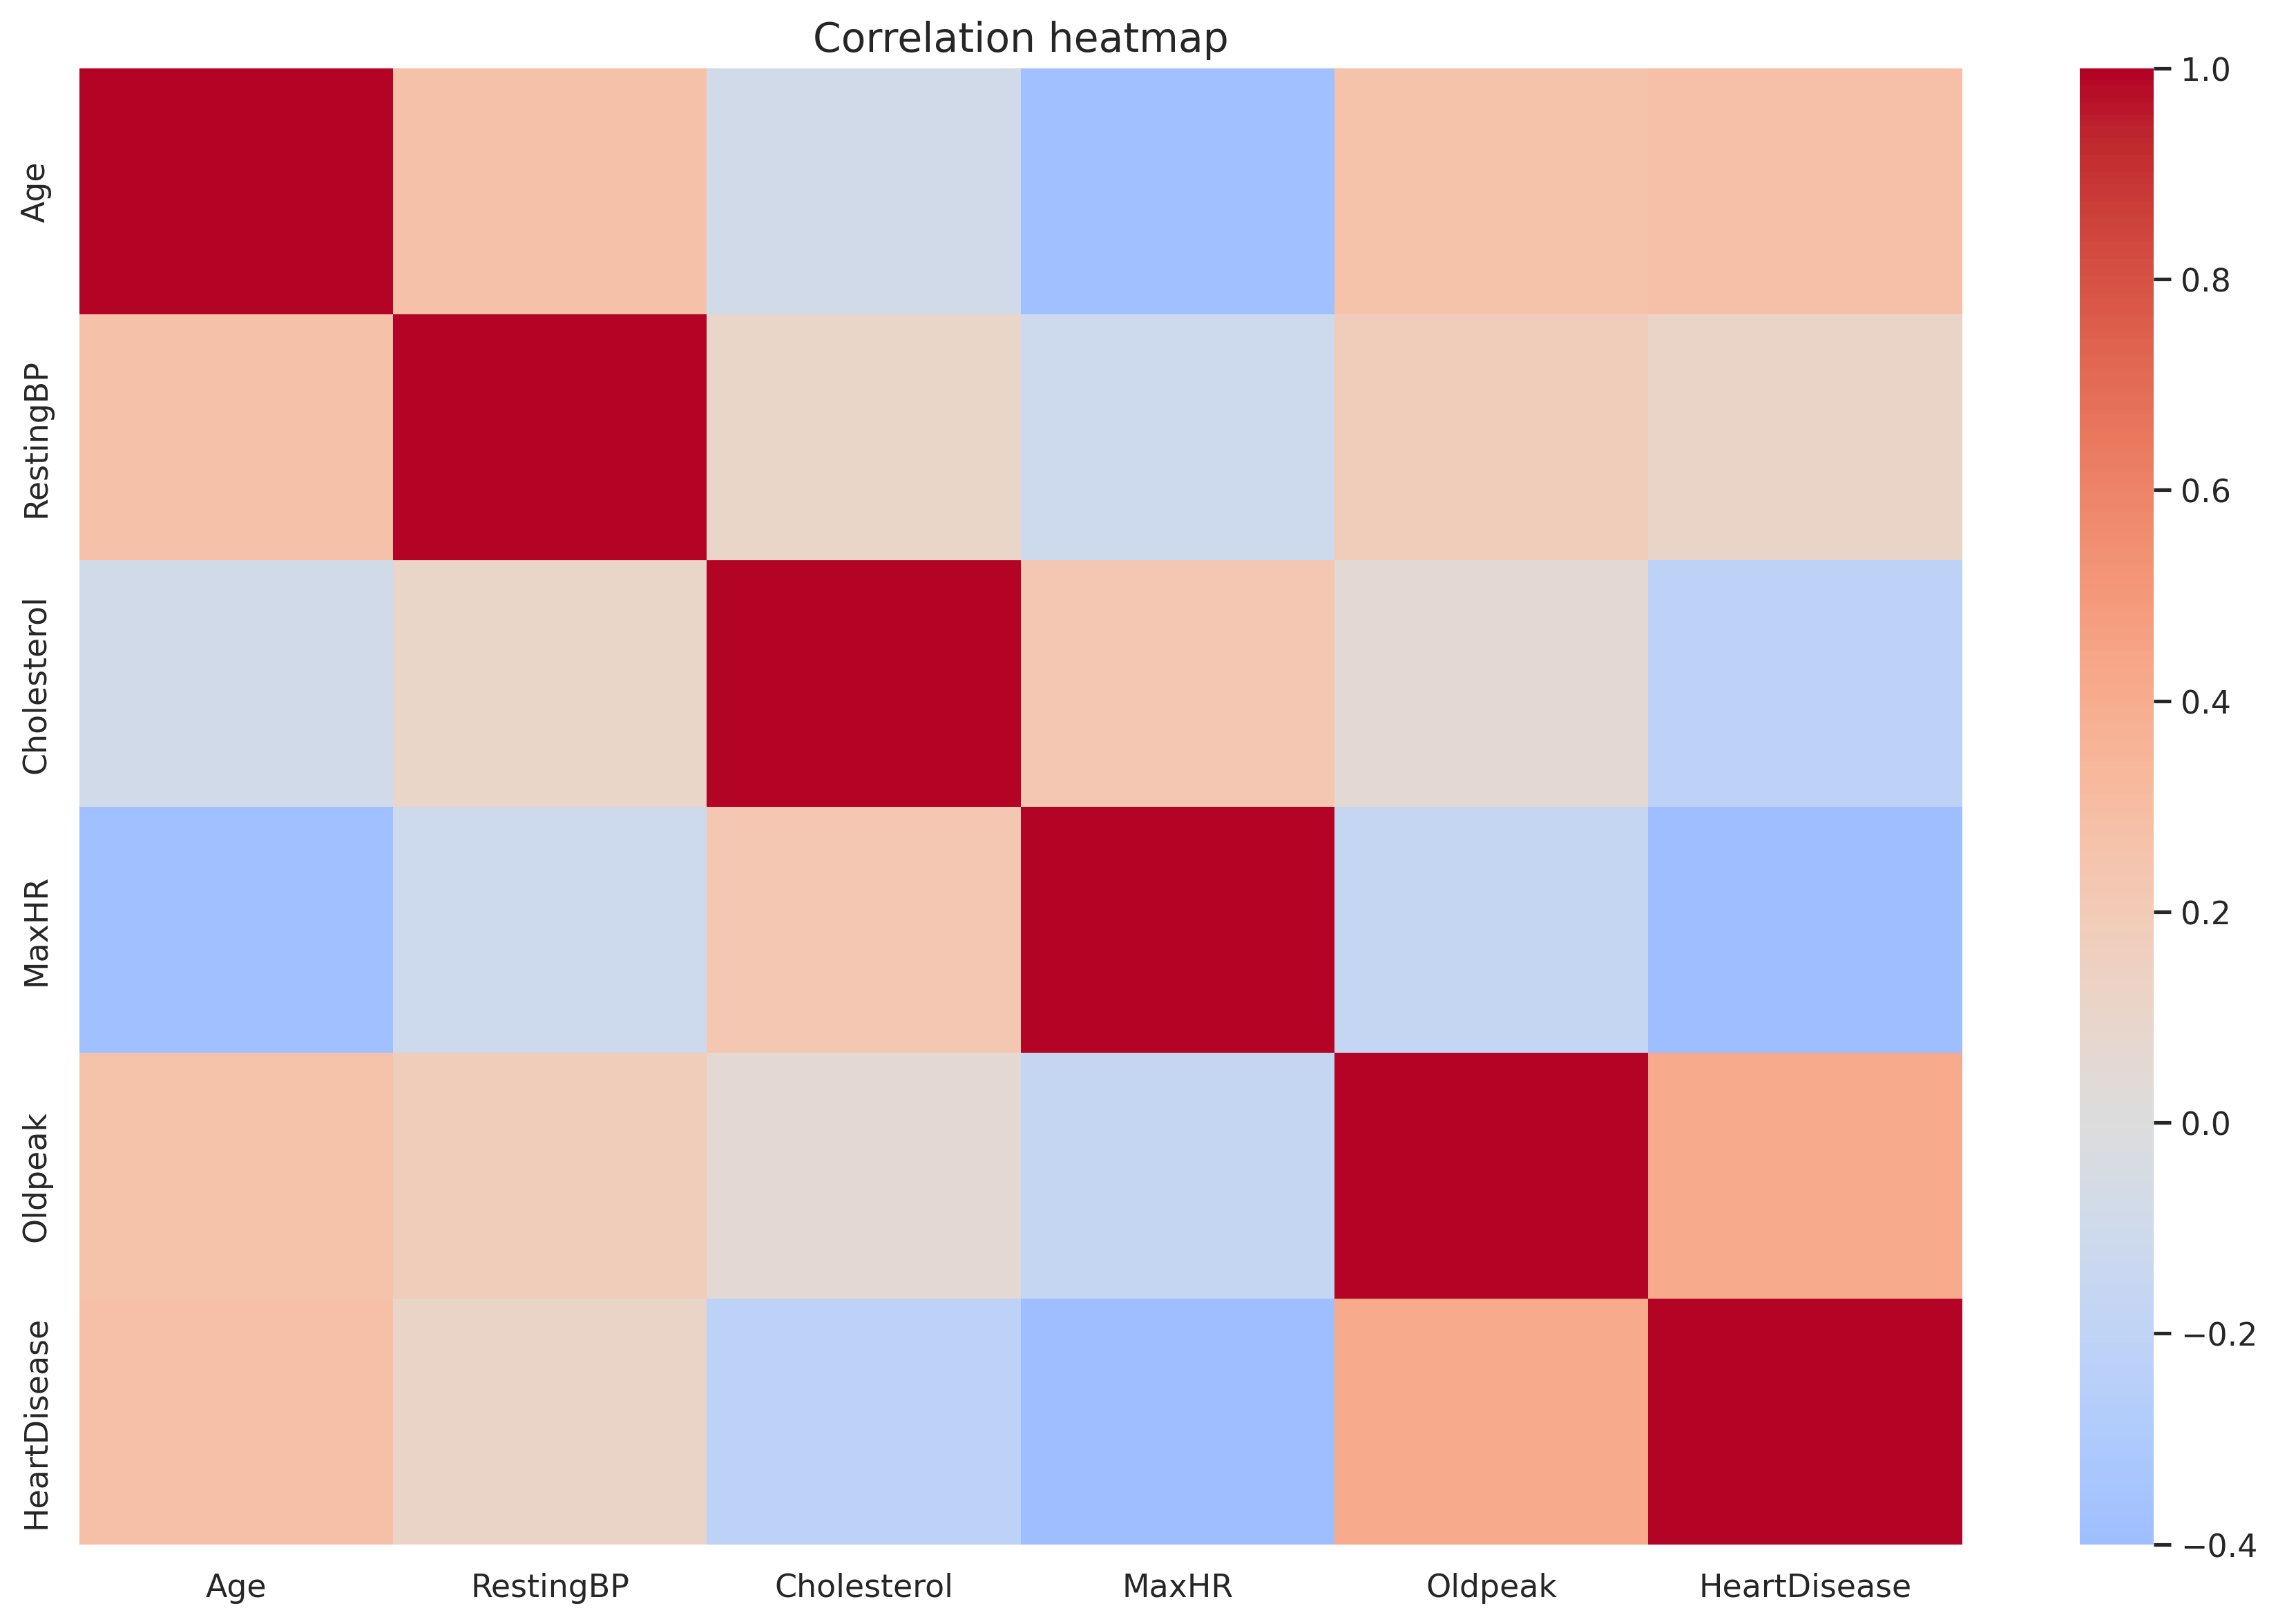

In [154]:
num_for_corr = [c for c in num_cols if c in df_clean.columns and c != target_col]
corr = df_clean[num_for_corr + [target_col]].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 5. Pattern mining

To apply pattern mining, we convert the numeric columns into bins and represent each patient as a transaction such as:

`age=high, chol=normal, cp=typical, target=1`

Then we mine frequent itemsets and association rules.  
The goal is not to replace classification, but to discover understandable relationships.

In [155]:
# Prepare a discretized copy for transactions
disc = df_clean.copy()

# Bin selected numeric columns into 3 groups when possible
for col in [c for c in num_for_corr if c != target_col]:
    try:
        disc[col] = pd.qcut(disc[col].rank(method="first"), q=3, labels=["low", "medium", "high"])
    except ValueError:
        # Fall back to equal-width bins if qcut fails
        disc[col] = pd.cut(disc[col], bins=3, labels=["low", "medium", "high"], include_lowest=True)

# Keep target as a string label
disc[target_col] = disc[target_col].astype(int).astype(str)

transactions = []
for _, row in disc.iterrows():
    items = []
    for col in disc.columns:
        items.append(f"{col}={row[col]}")
    transactions.append(items)

print("Example transaction:")
print(transactions[0][:10], "...")
print("Total transactions:", len(transactions))

Example transaction:
['Age=low', 'Sex=M', 'ChestPainType=ATA', 'RestingBP=medium', 'Cholesterol=high', 'FastingBS=0', 'RestingECG=Normal', 'MaxHR=high', 'ExerciseAngina=N', 'Oldpeak=low'] ...
Total transactions: 918


In [156]:
te = TransactionEncoder()
te_matrix = te.fit(transactions).transform(transactions)
trans_df = pd.DataFrame(te_matrix, columns=te.columns_)

frequent_itemsets = apriori(trans_df, min_support=0.12, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# Focus on rules that predict heart disease
if "consequents" in rules.columns:
    rules_hd = rules[rules["consequents"].astype(str).str.contains(f"{target_col}=1")]
else:
    rules_hd = rules.copy()

rules_hd = rules_hd.sort_values(["lift", "confidence", "support"], ascending=False)
rules_hd.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2466,"(ChestPainType=ASY, Sex=M, FastingBS=0, Oldpea...","(ExerciseAngina=Y, HeartDisease=1)",0.150327,0.344227,0.120915,0.804348,2.336681,1.0,0.069169,3.351731,0.673250,0.323615,0.701647,0.577807
2477,"(ChestPainType=ASY, FastingBS=0, Oldpeak=high)","(Sex=M, ExerciseAngina=Y, HeartDisease=1)",0.169935,0.314815,0.120915,0.711538,2.260181,1.0,0.067417,2.375309,0.671703,0.332335,0.579002,0.547811
1907,"(ChestPainType=ASY, FastingBS=0, Oldpeak=high)","(ExerciseAngina=Y, HeartDisease=1)",0.169935,0.344227,0.129630,0.762821,2.216042,1.0,0.071134,2.764883,0.661086,0.337110,0.638321,0.569701
1987,"(ChestPainType=ASY, ST_Slope=Flat, Oldpeak=high)","(ExerciseAngina=Y, HeartDisease=1)",0.163399,0.344227,0.124183,0.760000,2.207848,1.0,0.067937,2.732389,0.653920,0.323864,0.634020,0.560380
1996,"(ChestPainType=ASY, Sex=M, Oldpeak=high)","(ExerciseAngina=Y, HeartDisease=1)",0.208061,0.344227,0.157952,0.759162,2.205415,1.0,0.086332,2.722885,0.690167,0.400552,0.632743,0.609012
2475,"(Sex=M, ExerciseAngina=Y, Oldpeak=high)","(ChestPainType=ASY, FastingBS=0, HeartDisease=1)",0.200436,0.282135,0.120915,0.603261,2.138199,1.0,0.064365,1.809413,0.665758,0.334337,0.447335,0.515916
1017,"(ChestPainType=ASY, Oldpeak=high)","(ExerciseAngina=Y, HeartDisease=1)",0.236383,0.344227,0.173203,0.732719,2.128595,1.0,0.091833,2.453497,0.694336,0.425134,0.592419,0.617942
2002,"(ChestPainType=ASY, Oldpeak=high)","(Sex=M, ExerciseAngina=Y, HeartDisease=1)",0.236383,0.314815,0.157952,0.668203,2.122526,1.0,0.083535,2.065072,0.692577,0.401662,0.515755,0.584966
2370,"(MaxHR=low, ST_Slope=Flat, Sex=M)","(ExerciseAngina=Y, HeartDisease=1)",0.206972,0.344227,0.144880,0.700000,2.033544,1.0,0.073635,2.185911,0.640895,0.356568,0.542525,0.560443
2488,"(ChestPainType=ASY, ST_Slope=Flat, FastingBS=0...","(ExerciseAngina=Y, HeartDisease=1)",0.205882,0.344227,0.142702,0.693122,2.013562,1.0,0.071831,2.136917,0.633871,0.350267,0.532036,0.553839


## 6. Train-test split and preprocessing pipeline

We use a clean scikit-learn pipeline so preprocessing is learned only from the training data.

In [157]:
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_features = [c for c in X.columns if c not in cat_cols]
categorical_features = [c for c in cat_cols if c in X.columns]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Train shape: (734, 11)
Test shape: (184, 11)
Numeric features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Categorical features: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## 7. Basic classification models

We compare several classic algorithms:
- Logistic Regression
- K-Nearest Neighbors
- Naive Bayes
- Decision Tree
- SVM

This section represents the **basic classification** part of the course.

In [158]:
def get_score_vector(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return model.predict(X)

def evaluate_model(name, estimator):
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = get_score_vector(pipe, X_test)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, score),
        "pipeline": pipe,
    }
    return result

basic_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
}

basic_results = [evaluate_model(name, model) for name, model in basic_models.items()]
basic_df = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in basic_results])
basic_df.sort_values("f1", ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,f1,roc_auc
0,KNN,0.913043,0.921569,0.921569,0.921569,0.948589
1,SVM (RBF),0.902174,0.888889,0.941176,0.914286,0.946915
2,Logistic Regression,0.885870,0.871560,0.931373,0.900474,0.930177
3,Naive Bayes,0.875000,0.876190,0.901961,0.888889,0.911526
4,Decision Tree,0.793478,0.807692,0.823529,0.815534,0.789813


## 8. Advanced classification models

This section represents the **advanced classification** part of the course.
We try stronger ensemble and neural models, then compare them with the basic models.

In [159]:
advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42),
}

advanced_results = [evaluate_model(name, model) for name, model in advanced_models.items()]
advanced_df = pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in advanced_results])
advanced_df.sort_values("f1", ascending=False).reset_index(drop=True)

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.896739,0.895238,0.921569,0.908213,0.937171
1,Extra Trees,0.891304,0.879630,0.931373,0.904762,0.944524
2,Gradient Boosting,0.885870,0.900990,0.892157,0.896552,0.935079
3,AdaBoost,0.885870,0.900990,0.892157,0.896552,0.920851
4,MLP,0.847826,0.870000,0.852941,0.861386,0.899211


In [160]:
results_df = pd.concat([basic_df, advanced_df], ignore_index=True)
results_df = results_df.sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,KNN,0.913043,0.921569,0.921569,0.921569,0.948589
1,SVM (RBF),0.902174,0.888889,0.941176,0.914286,0.946915
2,Random Forest,0.896739,0.895238,0.921569,0.908213,0.937171
3,Extra Trees,0.891304,0.879630,0.931373,0.904762,0.944524
4,Logistic Regression,0.885870,0.871560,0.931373,0.900474,0.930177
5,Gradient Boosting,0.885870,0.900990,0.892157,0.896552,0.935079
6,AdaBoost,0.885870,0.900990,0.892157,0.896552,0.920851
7,Naive Bayes,0.875000,0.876190,0.901961,0.888889,0.911526
8,MLP,0.847826,0.870000,0.852941,0.861386,0.899211
9,Decision Tree,0.793478,0.807692,0.823529,0.815534,0.789813


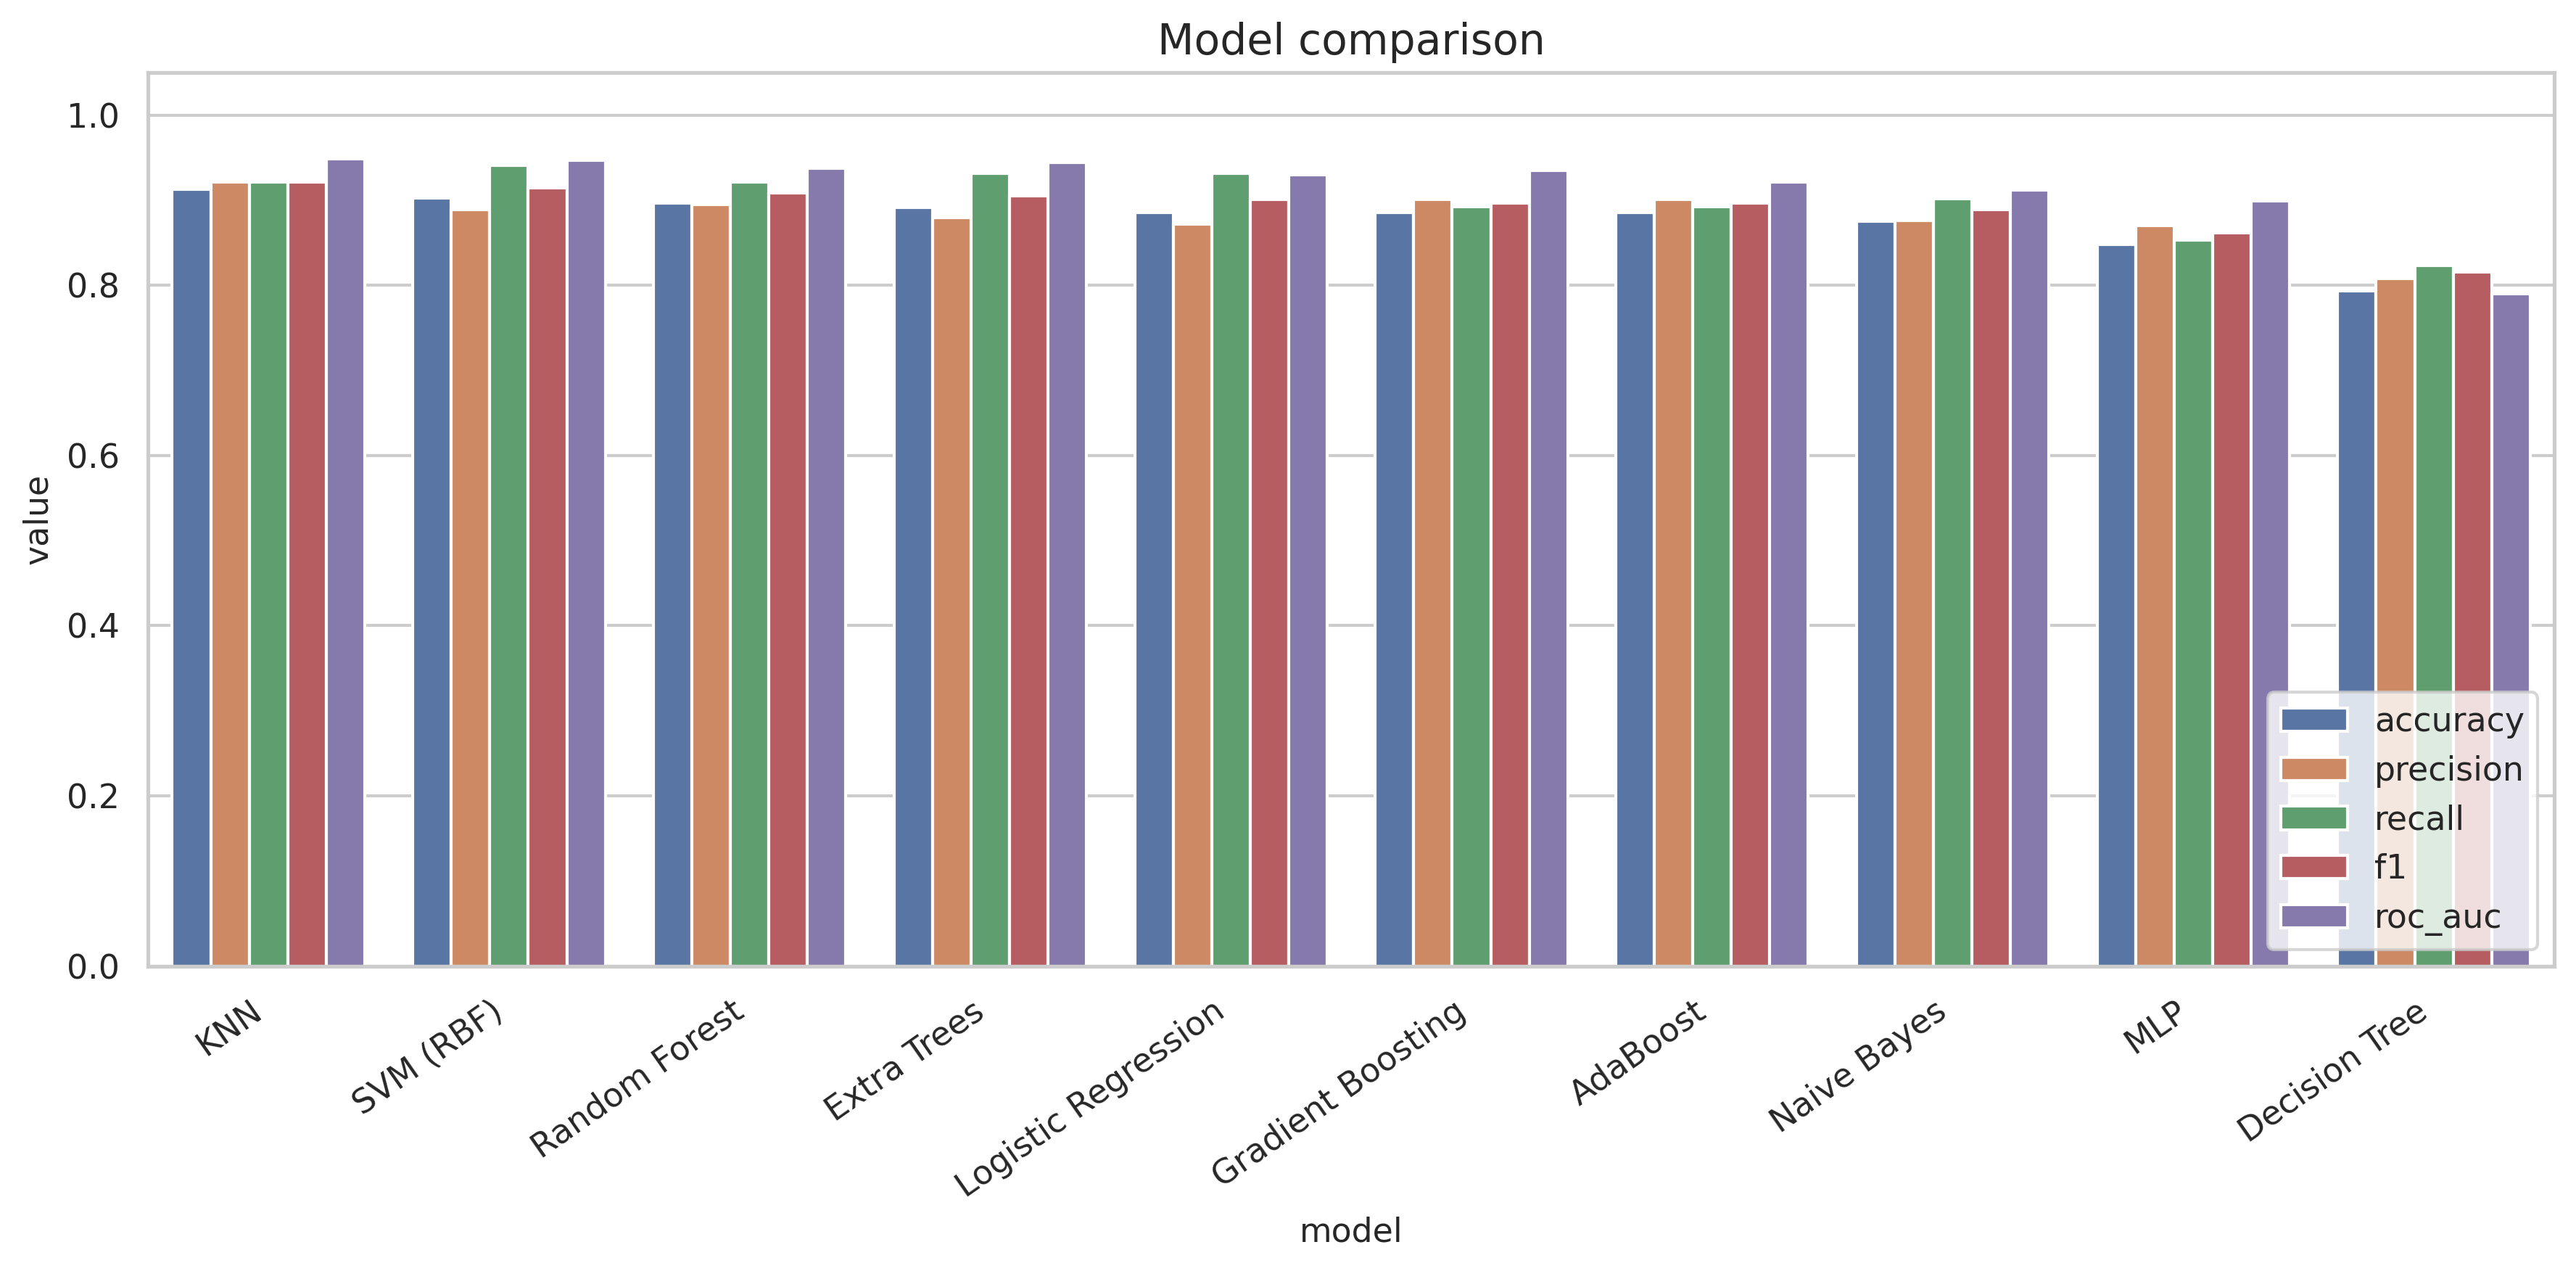

In [161]:
plt.figure(figsize=(12, 6))
plot_df = results_df.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"])
sns.barplot(data=plot_df, x="model", y="value", hue="variable")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.title("Model comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Hyperparameter tuning on the strongest candidate

Use the best model from the comparison table as the starting point.
A good practical choice for this dataset is often a tree-based ensemble because it handles mixed clinical features well.

In [162]:
top_model_name = results_df["model"]
top_model_name

,model
0,KNN
1,SVM (RBF)
2,Random Forest
3,Extra Trees
4,Logistic Regression
5,Gradient Boosting
6,AdaBoost
7,Naive Bayes
8,MLP
9,Decision Tree


Although KNN achieved the highest F1 score in the comparison,
it offers no feature importance or interpretability — a critical
requirement in clinical settings. Random Forest ranks 3rd overall
but provides feature importances, making it the preferred choice
for deployment.

In [163]:
# Tune a Random Forest as a strong and interpretable advanced model
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(random_state=42)),
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid.fit(X_train, y_train)

print("Best CV F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best CV F1: 0.8867165920412997
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}


## 10. Final evaluation of the tuned model

In [164]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)
best_score = get_score_vector(best_model, X_test)

final_metrics = {
    "accuracy": accuracy_score(y_test, best_pred),
    "precision": precision_score(y_test, best_pred, zero_division=0),
    "recall": recall_score(y_test, best_pred, zero_division=0),
    "f1": f1_score(y_test, best_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, best_score),
}

final_metrics

{'accuracy': 0.8967391304347826,
 'precision': 0.8878504672897196,
 'recall': 0.9313725490196079,
 'f1': 0.9090909090909091,
 'roc_auc': np.float64(0.9365136298421808)}

              precision    recall  f1-score   support

           0       0.91      0.85      0.88        82
           1       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



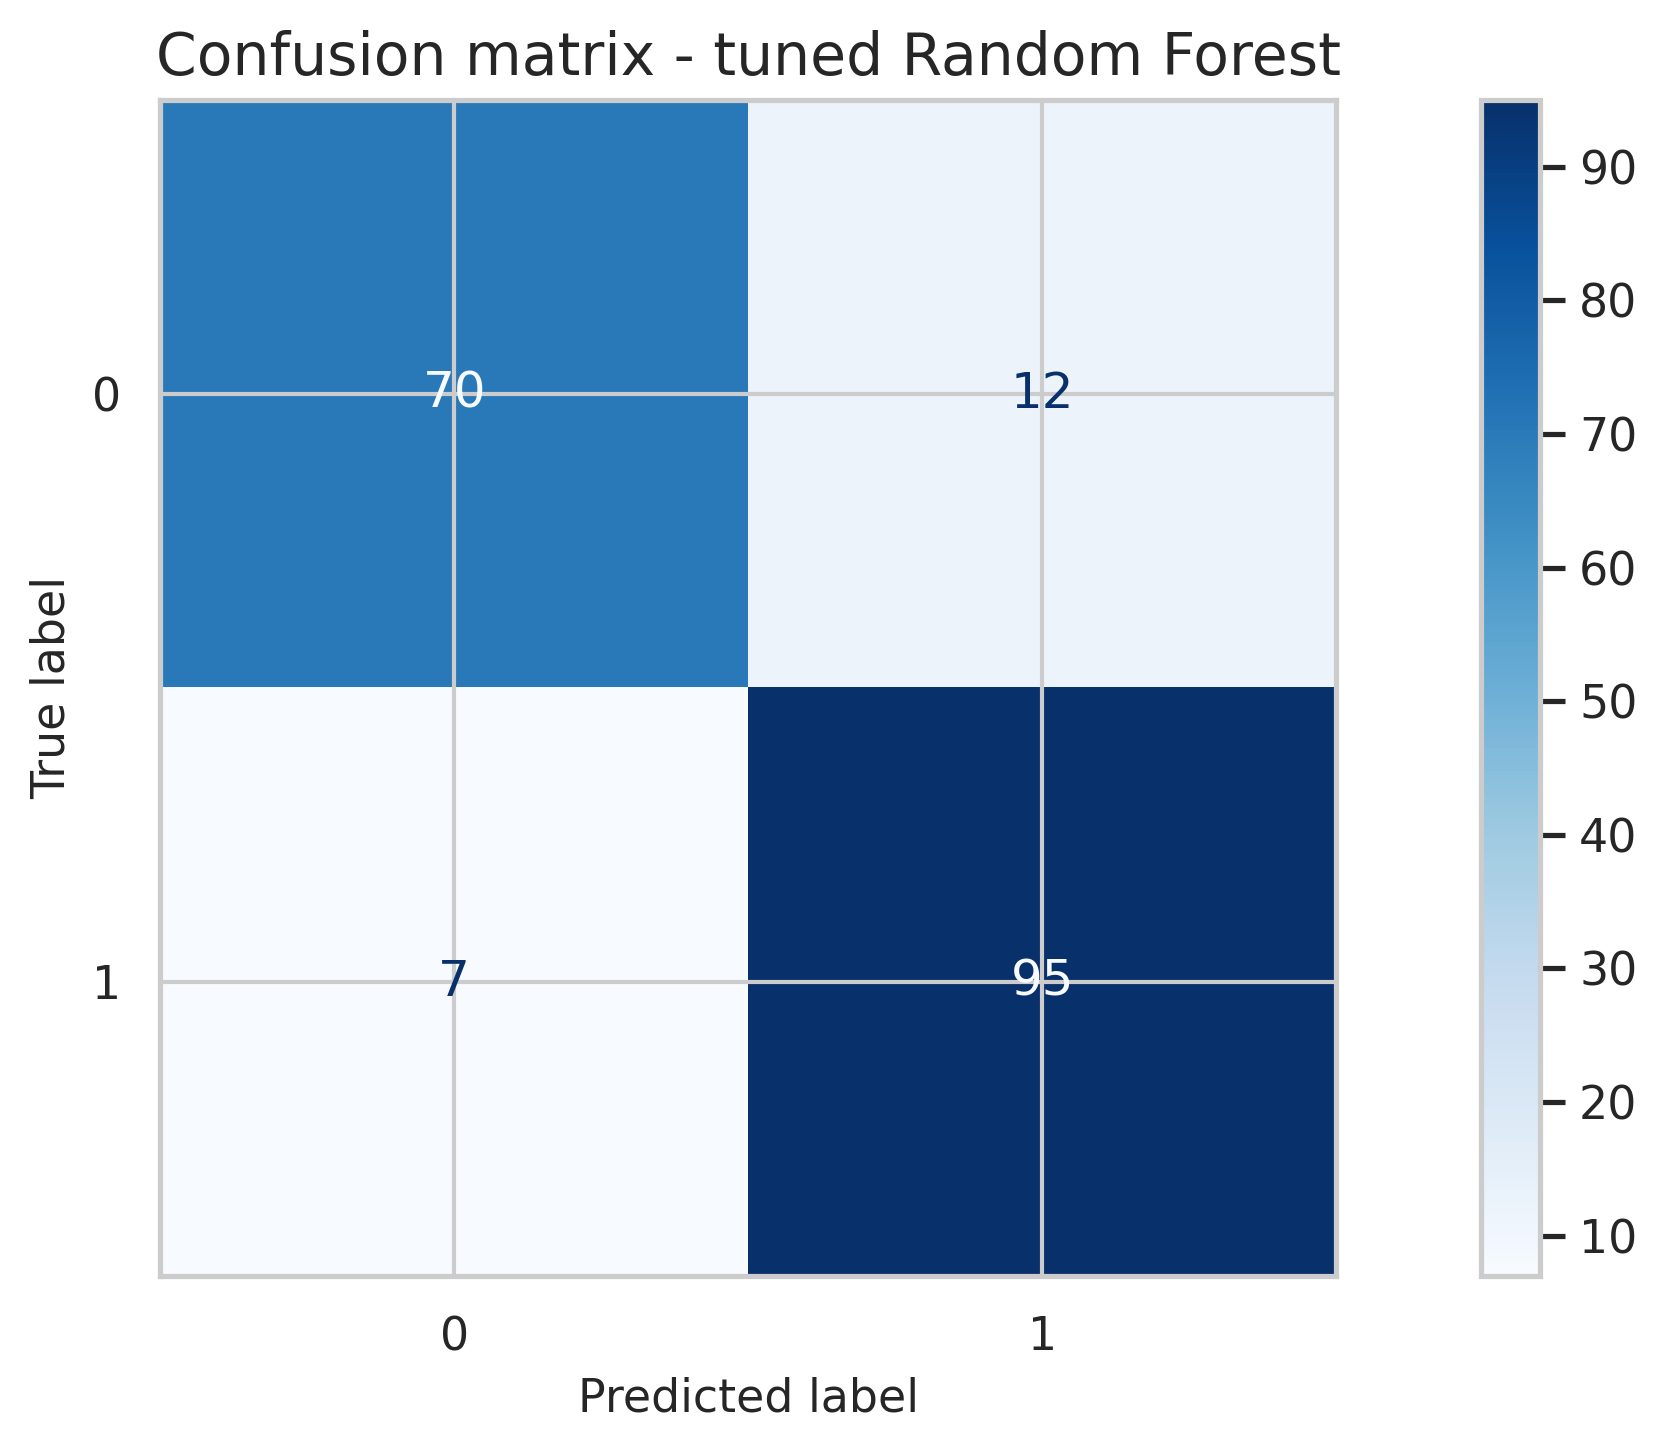

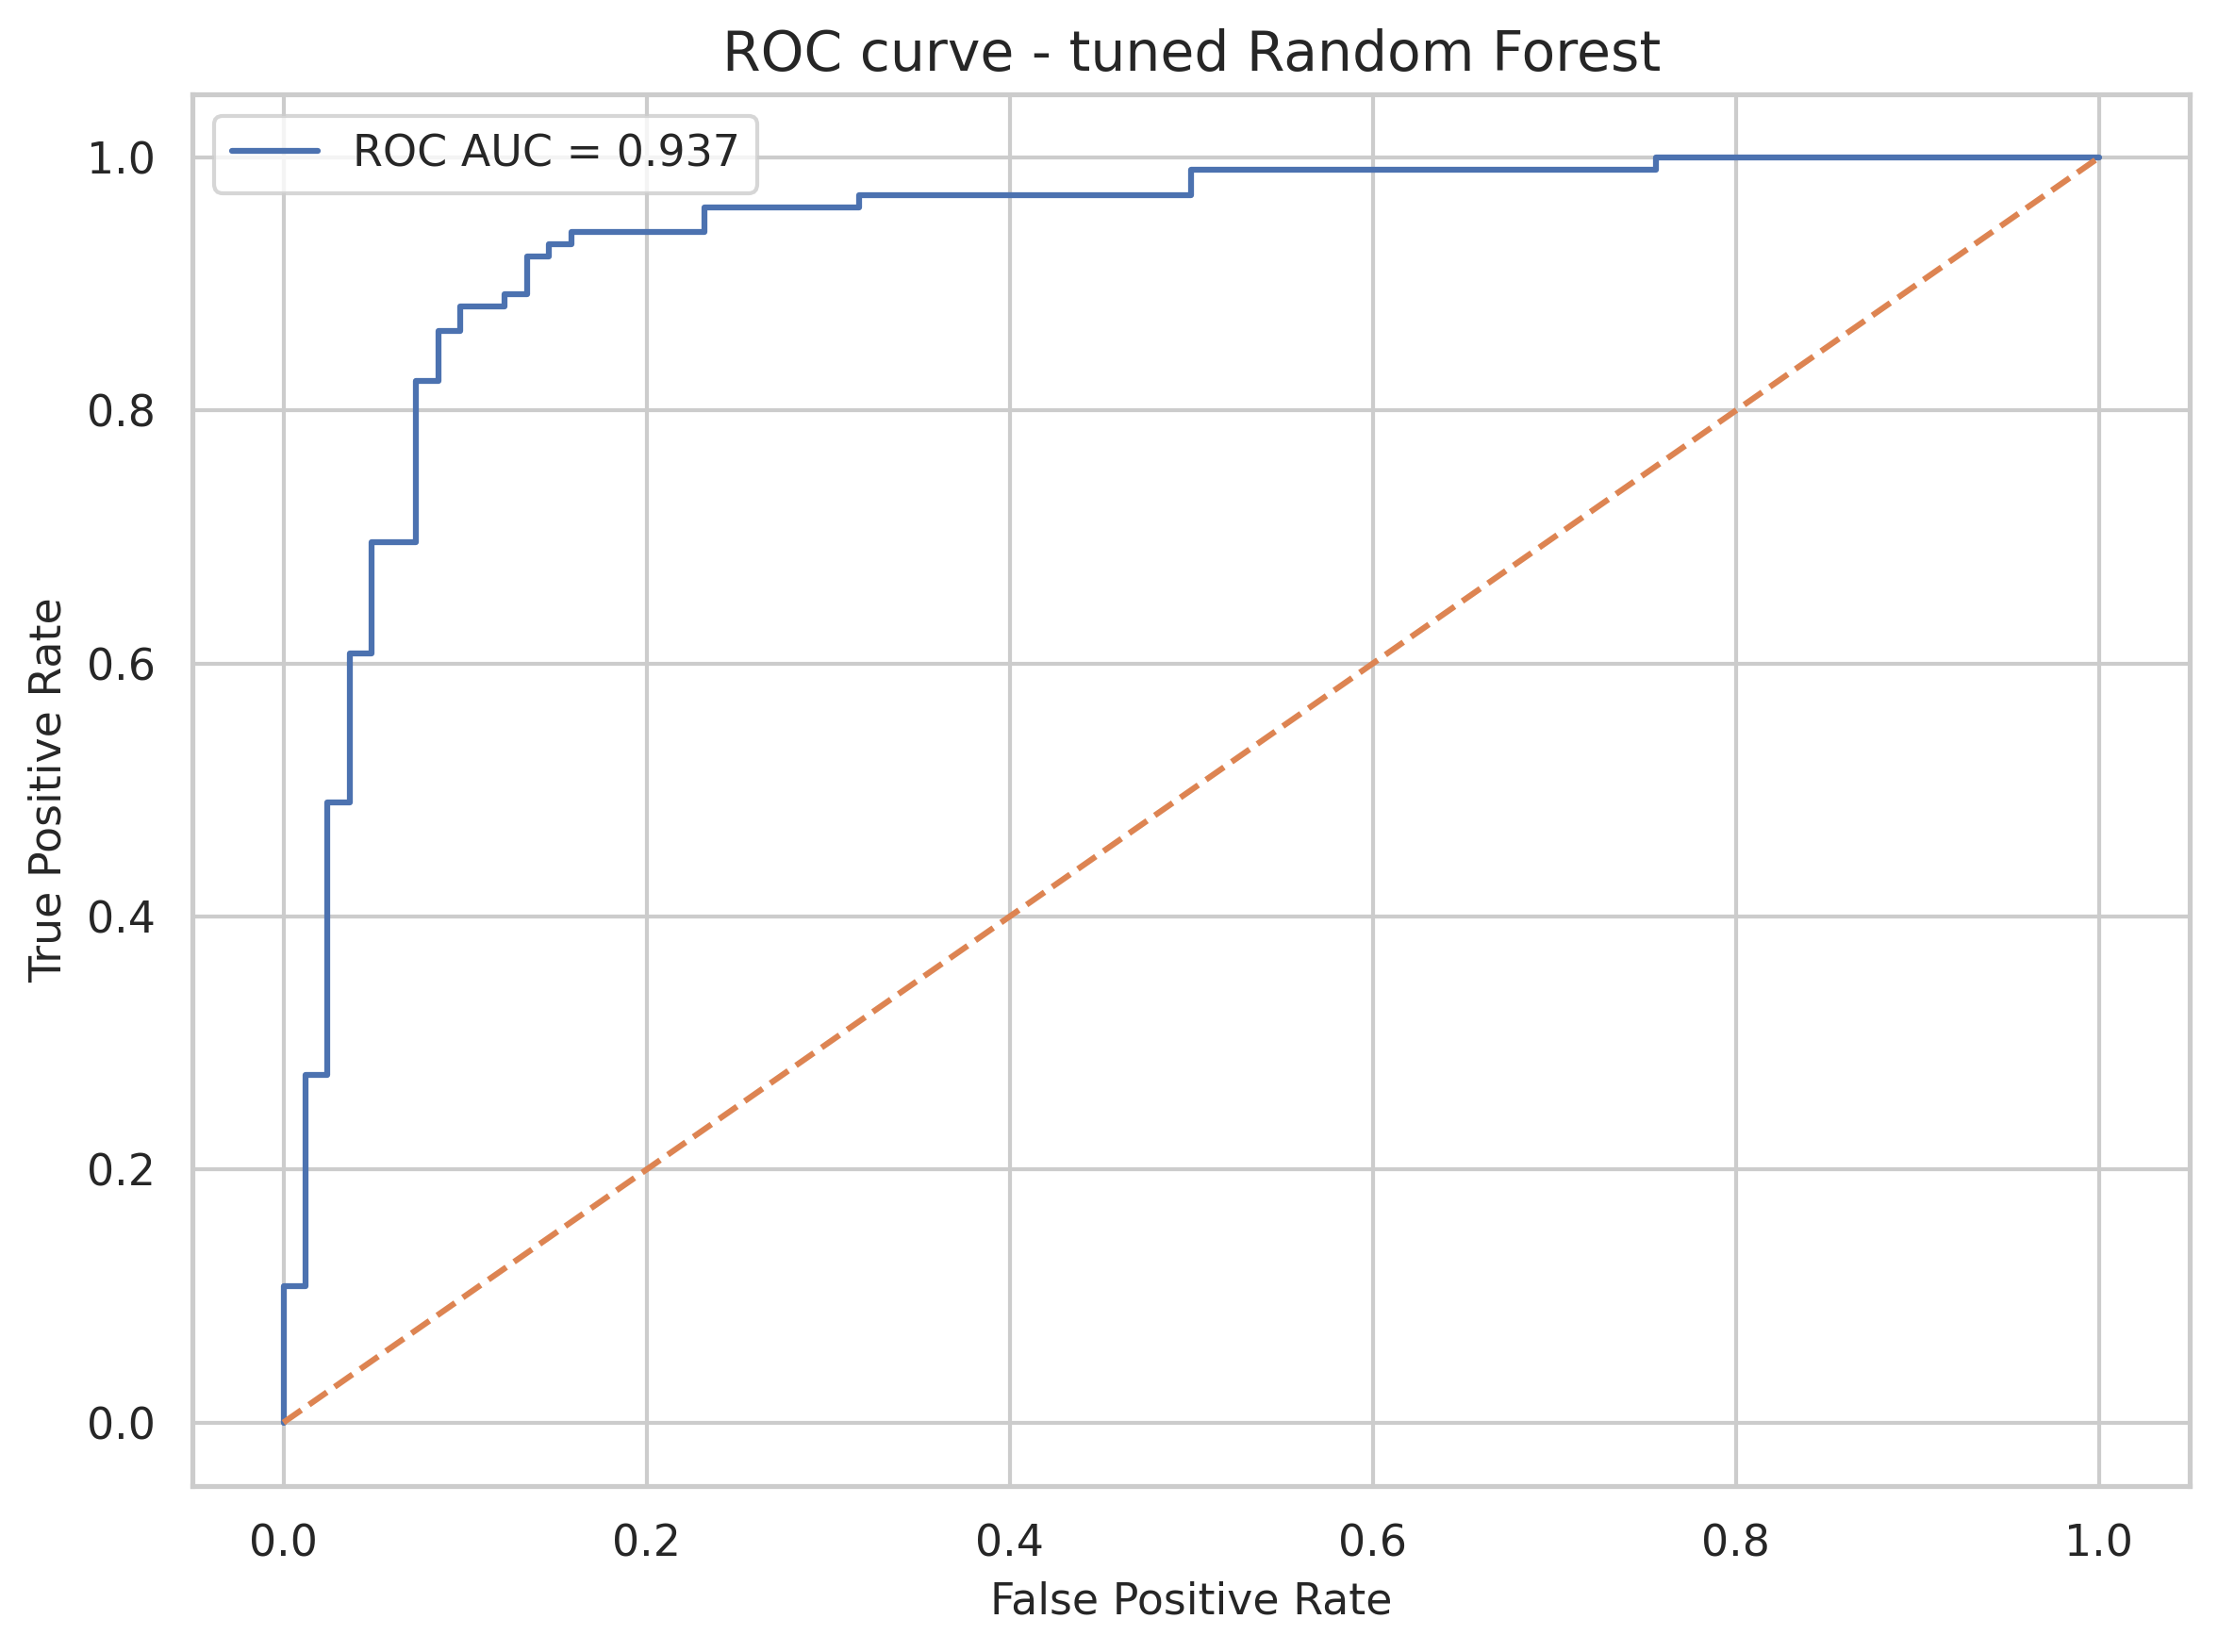

In [165]:
print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion matrix - tuned Random Forest")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, best_score)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {final_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - tuned Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Feature importance

Tree-based models give a useful picture of which features contribute most to the prediction.

In [166]:
# Get encoded feature names
preprocessor = best_model.named_steps["preprocess"]
feature_names = []

if len(numeric_features) > 0:
    feature_names.extend(numeric_features)

if len(categorical_features) > 0:
    ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    feature_names.extend(cat_names)

importances = best_model.named_steps["model"].feature_importances_
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False)

imp_df.head(15)

,feature,importance
20,ST_Slope_Up,0.182685
19,ST_Slope_Flat,0.111267
7,ChestPainType_ASY,0.095854
4,Oldpeak,0.089525
3,MaxHR,0.080525
2,Cholesterol,0.079342
17,ExerciseAngina_Y,0.059779
0,Age,0.056195
16,ExerciseAngina_N,0.051382
1,RestingBP,0.049880


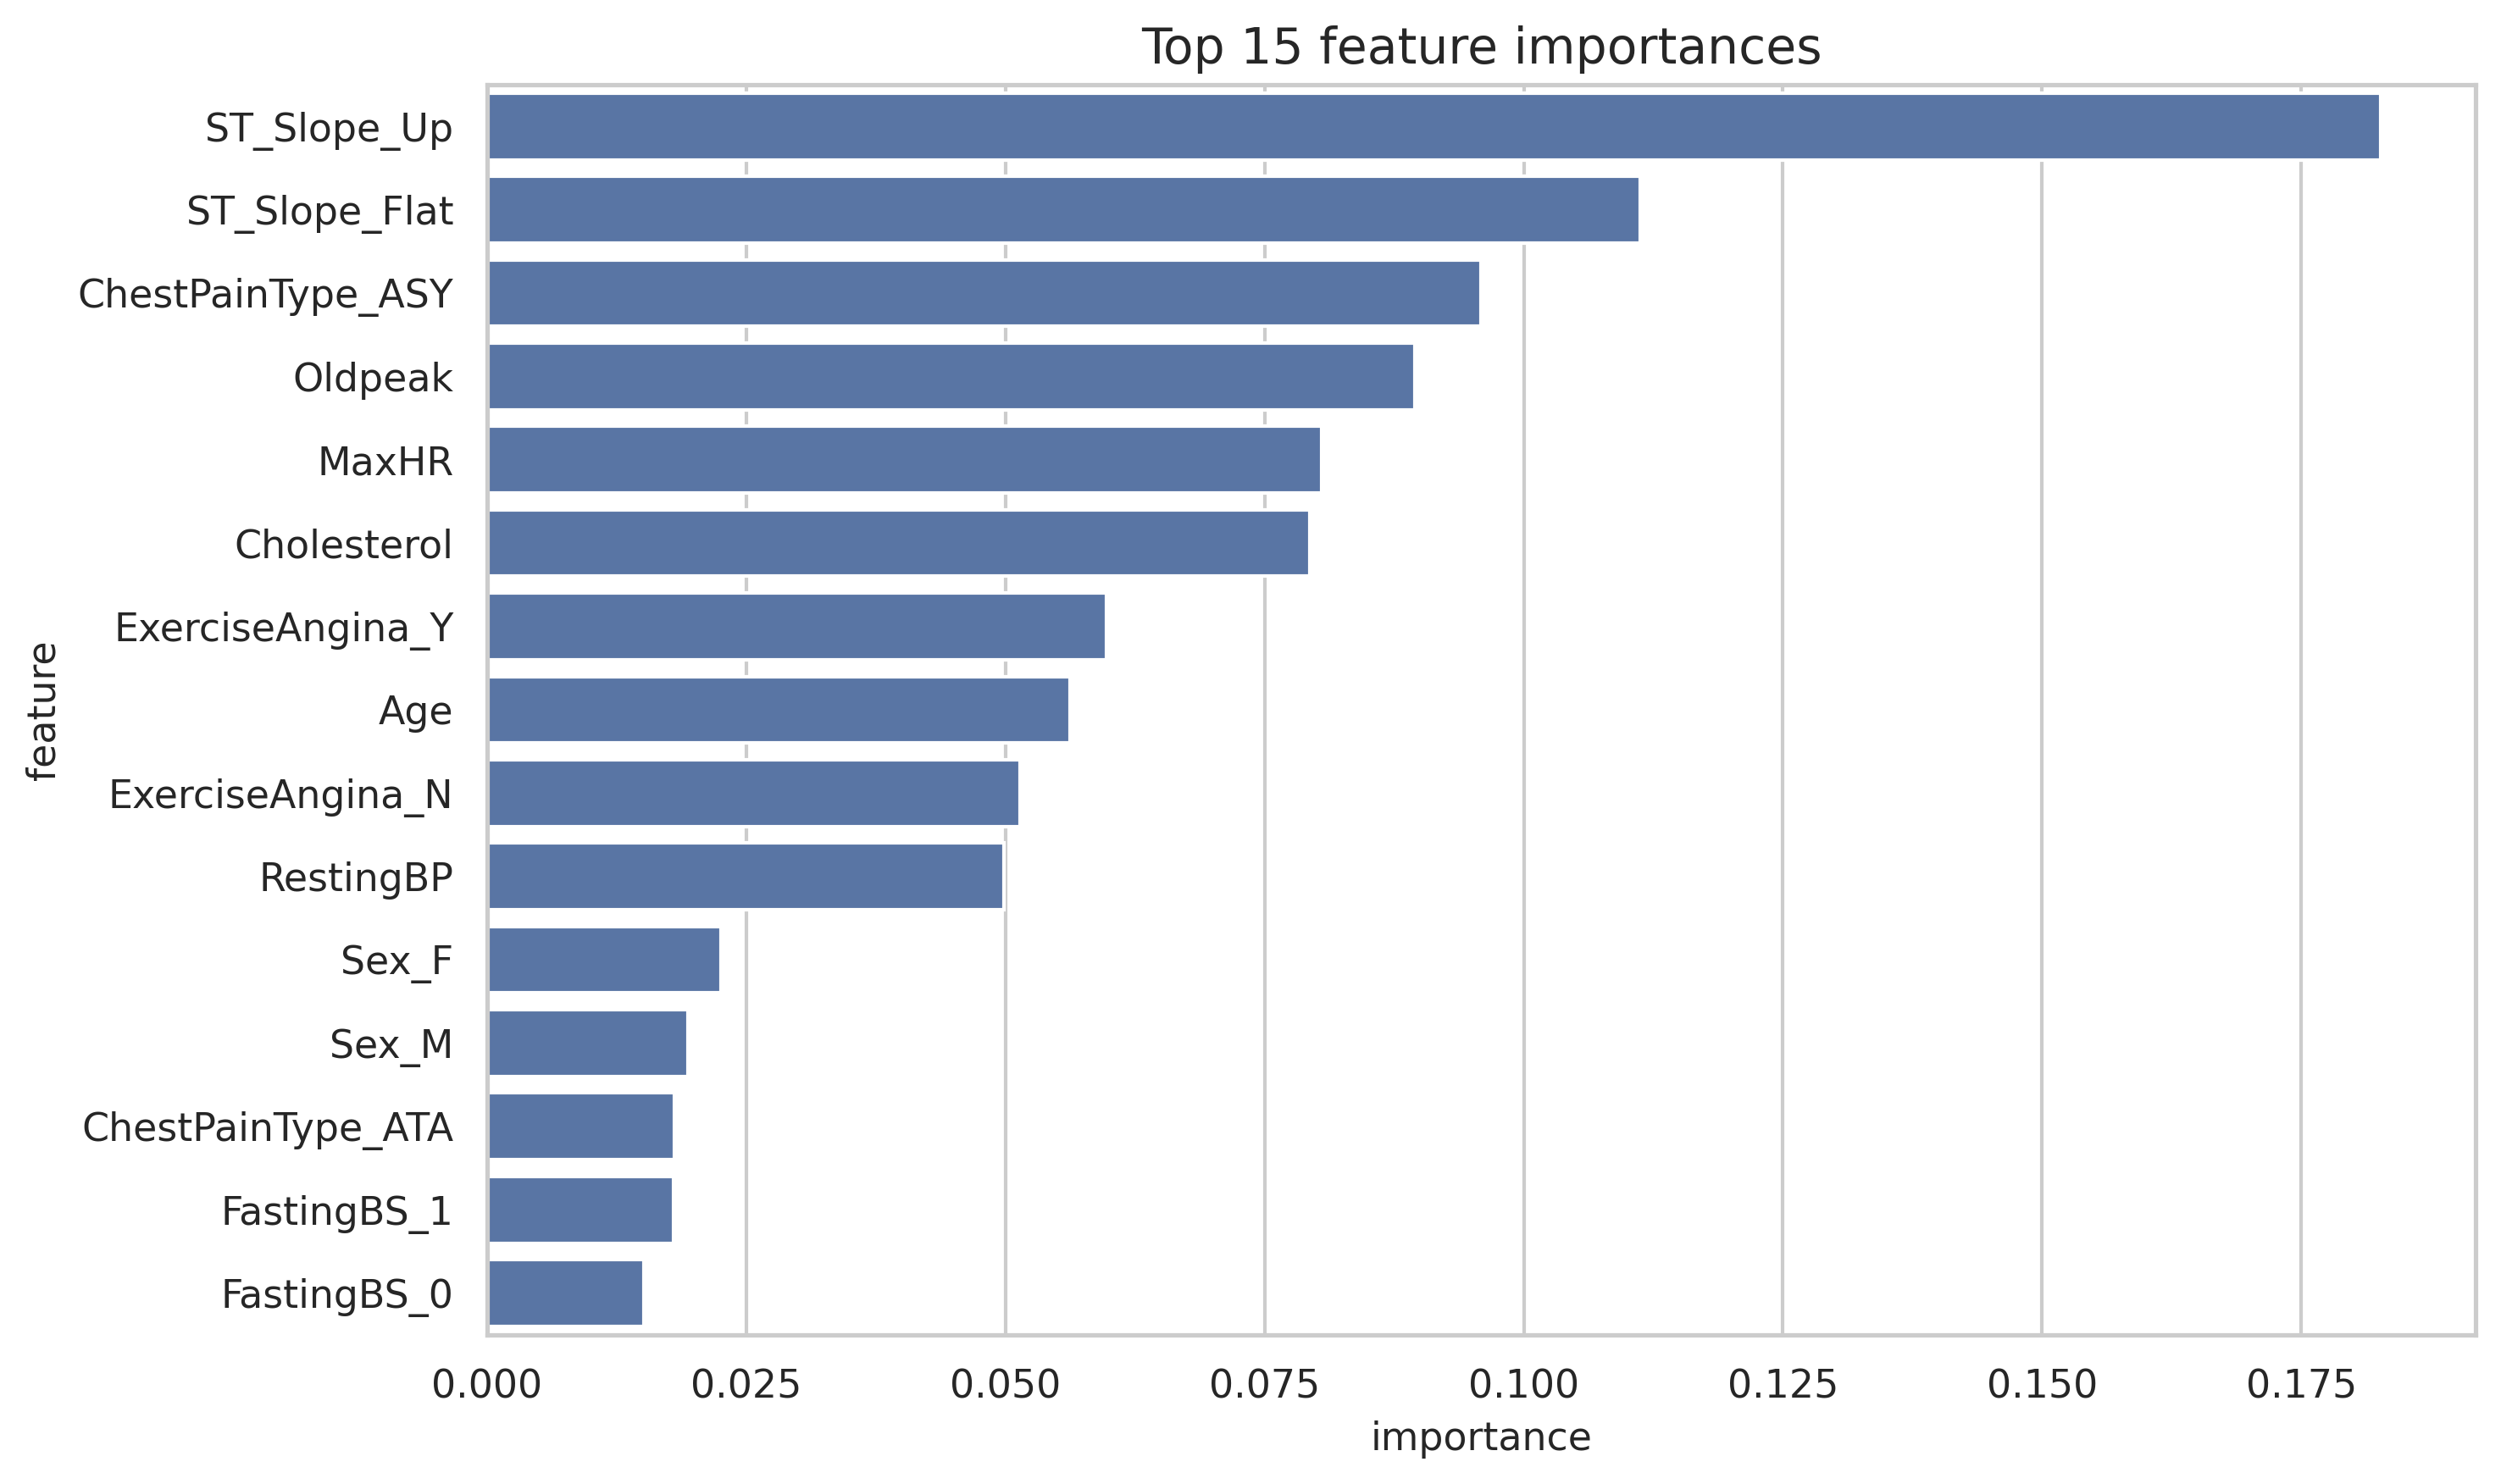

In [167]:
plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(15), x="importance", y="feature")
plt.title("Top 15 feature importances")
plt.tight_layout()
plt.show()

## 12. Save the model

The saved pipeline includes both preprocessing and the trained classifier, so it can be reused later on new patient data.

In [168]:
import joblib

output_model = "heart_disease_best_model.joblib"
joblib.dump(best_model, output_model)
print(f"Saved model to: {output_model}")

Saved model to: heart_disease_best_model.joblib


## 13. Conclusion

This project shows a complete data-mining workflow for heart disease prediction:

- **Preprocessing:** cleaned duplicates, handled missing values, encoded categorical variables, scaled numeric features, and clipped extreme values.
- **Pattern mining:** converted patient records into transactions and mined association rules that can reveal clinically interesting combinations.
- **Basic classification:** compared standard algorithms such as Logistic Regression, KNN, Naive Bayes, Decision Tree, and SVM.
- **Advanced classification:** tested ensemble and neural models, then tuned a Random Forest classifier.


# 14. Prediction testing

## Load model

In [169]:
import joblib

# Load model
model = joblib.load("heart_disease_best_model.joblib")

## Create input sample

In [170]:
import pandas as pd

# Example patient data
sample = {
    'Age': 55,
    'Sex': 'M',
    'ChestPainType': 'ATA',
    'RestingBP': 130,
    'Cholesterol': 250,
    'FastingBS': 0,
    'RestingECG': 'Normal',
    'MaxHR': 150,
    'ExerciseAngina': 'N',
    'Oldpeak': 1.2,
    'ST_Slope': 'Up'
}

sample_df = pd.DataFrame([sample])

## Predict the sample

In [171]:
def predict_heart_disease(model, input_data):
    df = pd.DataFrame([input_data])
    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]

    if pred == 1:
        print(f"⚠️ High risk of heart disease ({prob:.2f})")
    else:
        print(f"✅ Low risk ({prob:.2f})")

# Test
print("Sample patient data:")
for key, value in sample.items():
    print(f"  {key}: {value}")
predict_heart_disease(model, sample)

Sample patient data:
  Age: 55
  Sex: M
  ChestPainType: ATA
  RestingBP: 130
  Cholesterol: 250
  FastingBS: 0
  RestingECG: Normal
  MaxHR: 150
  ExerciseAngina: N
  Oldpeak: 1.2
  ST_Slope: Up
✅ Low risk (0.10)
